In [1]:
%load_ext rpy2.ipython

In [2]:
%%R

library(DESeq2)
library(dplyr)
library(tidyverse)
library(ggplot2)
library(RColorBrewer)
library(pheatmap)
library(tximport)
library(ggrepel)
library(GenomicFeatures)
library(AnnotationHub)
library(ensembldb)
library(stringr)
library(biomaRt)
library("pheatmap")
library(EnhancedVolcano)
library("org.Mm.eg.db")
library("gprofiler2")
library("ChIPpeakAnno")
library('TxDb.Mmusculus.UCSC.mm10.ensGene')
library("ChIPseeker")
library(clusterProfiler)
library(stringr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.2     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%() masks IRanges::%within%()
✖ dplyr::collapse()     masks IRanges::collapse()
✖ dplyr::combine()      masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::count()        masks matrixStats::count()
✖ dplyr::desc()         masks IRanges::desc()
✖ tidyr::expand()       masks S4Vectors::expand()
✖ dplyr::filter()       masks stats::filter()
✖ dplyr::first()        masks S4Vectors::first()
✖ dplyr::lag()          masks stats::lag()
✖ ggplot2::Position()   masks BiocGenerics::Position(), base::Position()
✖ purrr::reduce()       masks GenomicRanges::reduce(), IRanges::reduce()
✖ dplyr::rename()       masks S4Vectors::rename()
✖ lubridate::second()  

Loading required package: S4Vectors
Loading required package: stats4
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min


Attaching package: ‘S4Vectors’

The following object is masked from ‘package:utils’:

    findMatches

The following objects are masked from ‘package:base’:

    expand.grid, I, unname

Loading required package: IRanges
Loading required package: GenomicRanges
Loading required package: GenomeInfoDb
Loading requ

### Get pseudobulk data from open-source scRNA-seq data of Old and Control samples

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import scanpy as sc
from adpbulk import ADPBulk

In [4]:
df = sc.read_h5ad('/tank/projects/kashuk_sirt6_hic/old_rnaseq/BrainAgingSpatialAtlas_snRNAseq.h5ad')

In [5]:
adpb = ADPBulk(df, ["cell_type", "age", "donor_id"], use_raw=True)

In [6]:
pseudobulk_matrix = adpb.fit_transform()

Aggregating Samples: 100%|██████████| 104/104 [00:01<00:00, 54.43it/s]


In [7]:
sample_meta = adpb.get_meta()
sample_meta.head(5)

,age,cell_type,donor_id,SampleName
0,4wk,T cell,10X_MsBrainAgingSpatialDonor_5,age.4wk-cell_type.T cell-donor_id.10X_MsBrainA...
1,4wk,T cell,10X_MsBrainAgingSpatialDonor_6,age.4wk-cell_type.T cell-donor_id.10X_MsBrainA...
2,4wk,astrocyte,10X_MsBrainAgingSpatialDonor_5,age.4wk-cell_type.astrocyte-donor_id.10X_MsBra...
3,4wk,astrocyte,10X_MsBrainAgingSpatialDonor_6,age.4wk-cell_type.astrocyte-donor_id.10X_MsBra...
4,4wk,cell,10X_MsBrainAgingSpatialDonor_5,age.4wk-cell_type.cell-donor_id.10X_MsBrainAgi...


In [8]:
pseudobulk_matrix

,ENSMUSG00000051951,ENSMUSG00000025900,ENSMUSG00000025902,ENSMUSG00000033845,ENSMUSG00000025903,ENSMUSG00000033813,ENSMUSG00000002459,ENSMUSG00000033793,ENSMUSG00000025905,ENSMUSG00000033774,...,ENSMUSG00000072844,ENSMUSG00000093806,ENSMUSG00000053211,ENSMUSG00000056673,ENSMUSG00000069049,ENSMUSG00000068457,ENSMUSG00000069045,ENSMUSG00000069044,ENSMUSG00000000103,ENSMUSG00000096256
age.4wk-cell_type.T cell-donor_id.10X_MsBrainAgingSpatialDonor_5,12.0,0.0,0.0,0.0,4.0,5.0,0.0,7.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
age.4wk-cell_type.T cell-donor_id.10X_MsBrainAgingSpatialDonor_6,2.0,0.0,0.0,0.0,1.0,1.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
age.4wk-cell_type.astrocyte-donor_id.10X_MsBrainAgingSpatialDonor_5,1869.0,6.0,1.0,235.0,484.0,727.0,24140.0,1127.0,37.0,0.0,...,17.0,20.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0
age.4wk-cell_type.astrocyte-donor_id.10X_MsBrainAgingSpatialDonor_6,1973.0,4.0,2.0,244.0,575.0,807.0,25663.0,1309.0,47.0,1.0,...,10.0,27.0,0.0,0.0,0.0,1.0,0.0,5.0,0.0,3.0
age.4wk-cell_type.cell-donor_id.10X_MsBrainAgingSpatialDonor_5,194.0,0.0,0.0,12.0,38.0,45.0,1284.0,65.0,4.0,0.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
age.4wk-cell_type.cell-donor_id.10X_MsBrainAgingSpatialDonor_6,186.0,3.0,0.0,14.0,38.0,55.0,1591.0,85.0,4.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
age.4wk-cell_type.endothelial cell-donor_id.10X_MsBrainAgingSpatialDonor_5,295.0,18.0,54.0,13.0,24.0,45.0,85.0,51.0,3.0,0.0,...,1.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0
age.4wk-cell_type.endothelial cell-donor_id.10X_MsBrainAgingSpatialDonor_6,199.0,17.0,80.0,14.0,56.0,58.0,120.0,68.0,7.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0
age.4wk-cell_type.inhibitory interneuron-donor_id.10X_MsBrainAgingSpatialDonor_5,63390.0,46.0,2.0,645.0,779.0,1951.0,2321.0,3230.0,123.0,0.0,...,22.0,33.0,1.0,0.0,0.0,2.0,0.0,15.0,0.0,33.0
age.4wk-cell_type.inhibitory interneuron-donor_id.10X_MsBrainAgingSpatialDonor_6,61143.0,30.0,3.0,563.0,768.0,1860.0,2120.0,3283.0,124.0,6.0,...,14.0,21.0,2.0,0.0,1.0,0.0,0.0,10.0,0.0,42.0


### Subsetting neurons

In [9]:
neuronal_types = ["inhibitory interneuron", "medium spiny neuron", "neuron"]

neuron_rows = pseudobulk_matrix[pseudobulk_matrix.index.str.contains("|".join(neuronal_types))]

### Subsetting by age: Control - 4 weeks, Old - 90 weeks

In [10]:
df_4wk = neuron_rows[neuron_rows.index.str.startswith("age.4wk")]
df_90wk = neuron_rows[neuron_rows.index.str.startswith("age.90wk")]

df_4wk.index = df_4wk.index.str.replace(r'cell_type\..*?-donor_id', 'donor_id', regex=True)
df_90wk.index = df_90wk.index.str.replace(r'cell_type\..*?-donor_id', 'donor_id', regex=True)

df_4wk_grouped = df_4wk.groupby(df_4wk.index).sum()
df_90wk_grouped = df_90wk.groupby(df_90wk.index).sum()

df_4wk_grouped.index = [f"4wk.sample{i+1}" for i in range(len(df_4wk_grouped))]
df_90wk_grouped.index = [f"90wk.sample{i+1}" for i in range(len(df_90wk_grouped))]

df_4wk_grouped_transposed = df_4wk_grouped.T
df_90wk_grouped_transposed = df_90wk_grouped.T

df_merged = df_4wk_grouped_transposed.merge(df_90wk_grouped_transposed, left_index=True, right_index=True, how="inner")  

df_merged.head(5)

#df_merged.to_csv('/tank/projects/kashuk_sirt6_hic/old_rnaseq/pseudobulk_expression_raw_counts_4wk_90wk.csv')

,4wk.sample1,4wk.sample2,90wk.sample1,90wk.sample2
ENSMUSG00000051951,342166.0,356709.0,299867.0,283446.0
ENSMUSG00000025900,107.0,124.0,85.0,116.0
ENSMUSG00000025902,9.0,20.0,2.0,5.0
ENSMUSG00000033845,4462.0,4362.0,3413.0,3380.0
ENSMUSG00000025903,4897.0,5211.0,4193.0,4687.0


## DESeq2 differential analysis

### Annotation

In [66]:
%%R

ah <- AnnotationHub()

mm10_ens <- query(ah, c("Mus musculus", "EnsDb"))
mm10_ens

mm10_ens <- mm10_ens[["AH109655"]]

genedb <- genes(mm10_ens, return.type = "data.frame")

head(genedb, 3)
genedb2 <- dplyr::select(genedb, gene_id, symbol)

txdb <- transcripts(mm10_ens, return.type = "data.frame")
head(txdb)
txdb2 <- dplyr::select(txdb, tx_id, gene_id)

tx2gene <- right_join(txdb2, genedb2, by='gene_id')
head(tx2gene)


               tx_id            gene_id  symbol
1 ENSMUST00000082387 ENSMUSG00000064336   mt-Tf
2 ENSMUST00000179436 ENSMUSG00000095742        
3 ENSMUST00000082388 ENSMUSG00000064337 mt-Rnr1
4 ENSMUST00000082389 ENSMUSG00000064338   mt-Tv
5 ENSMUST00000082390 ENSMUSG00000064339 mt-Rnr2
6 ENSMUST00000082391 ENSMUSG00000064340  mt-Tl1


snapshotDate(): 2024-10-28
loading from cache


### Read pseudobulk data for Old/Control samples

In [67]:
%%R

data <- read.csv("/tank/projects/kashuk_sirt6_hic/old_rnaseq/pseudobulk_expression_raw_counts_4wk_90wk.csv", sep=',', row.names = 1)
genotype <- factor(c(rep("Control", 2), rep("Old",2)))

meta <- data.frame(genotype, row.names = colnames(data))
meta

              genotype
X4wk.sample1   Control
X4wk.sample2   Control
X90wk.sample1      Old
X90wk.sample2      Old


### Normalization

In [68]:
%%R

dds <- DESeqDataSetFromMatrix(countData = data, colData = meta, design = ~ genotype)

dds <- estimateSizeFactors(dds)
sizeFactors(dds)

colSums(counts(dds))

normalized_counts <- counts(dds, normalized=TRUE)

converting counts to integer mode


### Quality control

In [69]:
%%R

rld <- rlog(dds, blind=TRUE)

#### PCA

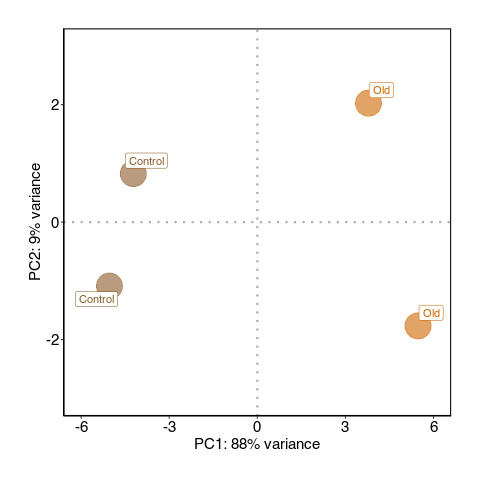

In [70]:
%%R

intgroup <- "genotype"
ntop <- 300

rv <- rowVars(assay(rld))

select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, length(rv)))]

pca <- prcomp(t(assay(rld)[select, ]))

percentVar <- pca$sdev^2/sum(pca$sdev^2)

intgroup.df <- as.data.frame(colData(rld)[, intgroup, drop = FALSE])
group <- if (length(intgroup) > 1) {
  factor(apply(intgroup.df, 1, paste, collapse = " : "))
} else {
  colData(rld)[[intgroup]]
}

d1 <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], intgroup.df, name = colnames(rld))

d1$genotype <- c(rep('Control', 2), rep('Old', 2))

ggplot(d1, aes(x=PC1, y=PC2, colour = genotype)) + 
  geom_point(size=12, alpha = 0.6) +
  ylim(-3, 3) + xlim(-6, 6) +
  xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
  ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) +
  geom_hline(yintercept = 0, linetype='dotted', col = 'darkgrey', size=1) +
  geom_vline(xintercept = 0, linetype='dotted', col = 'darkgrey', size=1) +
  theme_classic() +
  geom_label_repel(aes(label = genotype),
                   box.padding   = 0.3, 
                   point.padding = 0.1,
                   segment.color = 'grey50',
                   force         = 0.1,
                   segment.size  = 0.2,
                   max.overlaps = 100,
                   angle = 40
  ) +
  theme(axis.text.y   = element_text(size=15,colour = "black"),
        axis.text.x   = element_text(size=15,colour = "black"),
        axis.title.y  = element_text(size=15,colour = "black"),
        axis.title.x  = element_text(size=15,colour = "black"),
        axis.line = element_line(colour = "black"),
        panel.border = element_rect(colour = "black", fill=NA, size=1),
        legend.position = "none",
        aspect.ratio = 4/4,
        plot.margin = unit(c(1,1,1,1), "cm")
  ) +
  scale_colour_manual(values = c('tan4', 'darkorange3'))


#ggsave('/tank/projects/kashuk_sirt6_hic/supplement/PCA_old_control.pdf', dpi = 1200)

#### Correlation heatmap

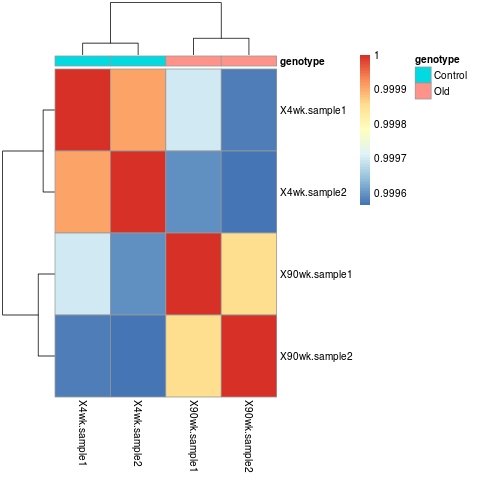

In [71]:
%%R

rld_mat <- assay(rld)

rld_cor <- cor(rld_mat)
pheatmap(rld_cor, annotation = meta)


### Statistical testing

using pre-existing size factors
estimating dispersions
gene-wise dispersion estimates
mean-dispersion relationship
final dispersion estimates
fitting model and testing
using 'normal' for LFC shrinkage, the Normal prior from Love et al (2014).

Note that type='apeglm' and type='ashr' have shown to have less bias than type='normal'.
See ?lfcShrink for more details on shrinkage type, and the DESeq2 vignette.
Reference: https://doi.org/10.1093/bioinformatics/bty895


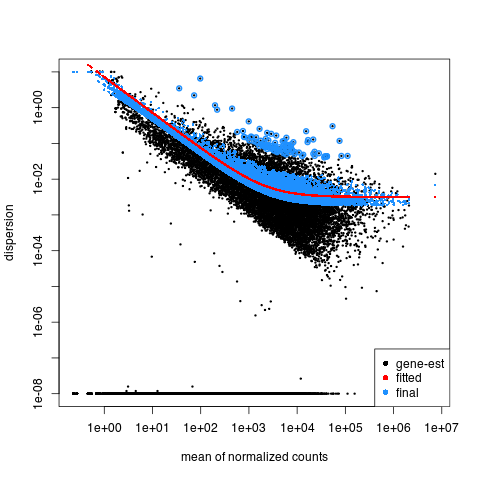

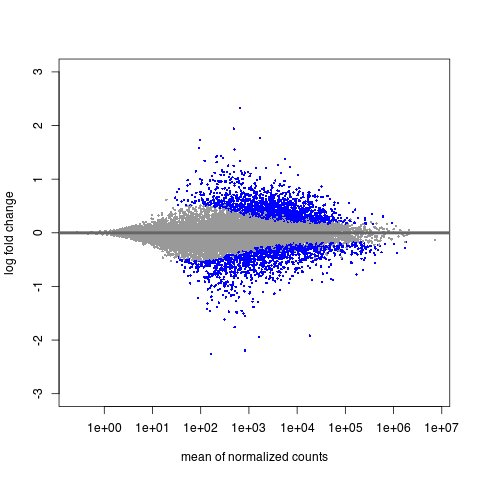

In [72]:
%%R

dds_analysis <- DESeq(dds)

plotDispEsts(dds_analysis)

contrast <- c("genotype", "Old", "Control")

res_unshrunken <- results(dds_analysis, contrast=contrast, alpha = 0.05)

res <- lfcShrink(dds_analysis, contrast=contrast, res=res_unshrunken, type='normal')

plotMA(res, ylim=c(-3,3))

In [73]:
%%R

summary(res)

padj.cutoff <- 0.05
lfc.cutoff <- 0

res_tb <- res %>% data.frame() %>% rownames_to_column(var="gene") %>% as_tibble()
sig <- res_tb %>%dplyr::filter(padj < padj.cutoff & abs(log2FoldChange) >= lfc.cutoff)

res.df <- as.data.frame(res)

res.df$gene_id <- rownames(res.df)
res.df.an <- left_join(res.df, genedb2, by='gene_id')

sig_old <- left_join(sig, genedb2, by=c('gene'='gene_id'))

#write.csv(sig_old, '/tank/projects/smirnov_rnaseq/kashuk_et_al/sig_genes_pvalue_0_05_Old_Control.csv')
#write.csv(res.df.an, '/tank/projects/smirnov_rnaseq/kashuk_et_al/all_genes_Old_Control.csv')


out of 20742 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 1779, 8.6%
LFC < 0 (down)     : 1347, 6.5%
outliers [1]       : 0, 0%
low counts [2]     : 4823, 23%
(mean count < 29)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



### Tximport for shSIRT6/shCtrl samples

In [74]:
%%R

samples <- list.files(path = "/tank/projects/kashuk_rnaseq/rnaseq/", full.names = T) 
samples

files <- file.path(samples, "quant.sf")
files

names(files) <- str_replace(samples, "/tank/projects/kashuk_rnaseq/rnaseq", "")
files


txi <- tximport(files, 
                type="salmon", 
                tx2gene=tx2gene[,c("tx_id", "gene_id")],
                countsFromAbundance="lengthScaledTPM")

attributes(txi)

data <- data.frame(round(txi$counts))

reading in files with read_tsv
1 2 3 4 5 
transcripts missing from tx2gene: 5640
summarizing abundance
summarizing counts
summarizing length


In [75]:
%%R

genotype <- factor(c(rep("shCtrl", 3), rep("shSIRT6",2)))

meta <- data.frame(genotype, row.names = colnames(data))
meta

                  genotype
X..shScrambled_R1   shCtrl
X..shScrambled_R2   shCtrl
X..shScrambled_R3   shCtrl
X..shSIRT6_R2      shSIRT6
X..shSIRT6_R3      shSIRT6


### Normalization

In [76]:
%%R

dds <- DESeqDataSetFromMatrix(countData = data, colData = meta, design = ~ genotype)

dds <- estimateSizeFactors(dds)
sizeFactors(dds)

colSums(counts(dds))

normalized_counts <- counts(dds, normalized=TRUE)

converting counts to integer mode


### Quality control

In [77]:
%%R

rld <- rlog(dds, blind=TRUE)

#### PCA

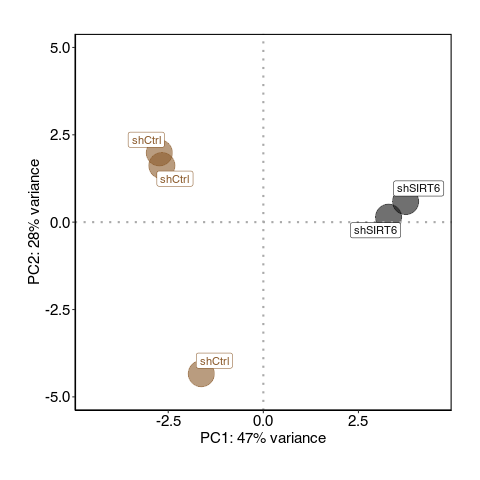

In [78]:
%%R

intgroup <- "genotype"
ntop <- 500

rv <- rowVars(assay(rld))

select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, length(rv)))]

pca <- prcomp(t(assay(rld)[select, ]))

percentVar <- pca$sdev^2/sum(pca$sdev^2)

intgroup.df <- as.data.frame(colData(rld)[, intgroup, drop = FALSE])
group <- if (length(intgroup) > 1) {
  factor(apply(intgroup.df, 1, paste, collapse = " : "))
} else {
  colData(rld)[[intgroup]]
}

d1 <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], intgroup.df, name = colnames(rld))

d1$genotype <- c(rep("shCtrl", 3), rep("shSIRT6",2))

ggplot(d1, aes(x=PC1, y=PC2, colour = genotype)) + 
  geom_point(size=12, alpha = 0.6) +
  ylim(-4.9, 4.9) + xlim(-4.5, 4.5) +
  xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
  ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) +
  geom_hline(yintercept = 0, linetype='dotted', col = 'darkgrey', size=1) +
  geom_vline(xintercept = 0, linetype='dotted', col = 'darkgrey', size=1) +
  theme_classic() +
  geom_label_repel(aes(label = genotype),
                   box.padding   = 0.3, 
                   point.padding = 0.1,
                   segment.color = 'grey50',
                   force         = 0.1,
                   segment.size  = 0.2,
                   max.overlaps = 100,
                   angle = 40
  ) +
  theme(axis.text.y   = element_text(size=15,colour = "black"),
        axis.text.x   = element_text(size=15,colour = "black"),
        axis.title.y  = element_text(size=15,colour = "black"),
        axis.title.x  = element_text(size=15,colour = "black"),
        axis.line = element_line(colour = "black"),
        panel.border = element_rect(colour = "black", fill=NA, size=1),
        legend.position = "none",
        aspect.ratio = 4/4,
        plot.margin = unit(c(1,1,1,1), "cm")
  ) +
  scale_colour_manual(values = c('tan4', 'gray7'))

#ggsave('/tank/projects/kashuk_sirt6_hic/supplement/PCA_shSIRT6_shCtrl.pdf', dpi = 1200)

#### Correlation heatmap

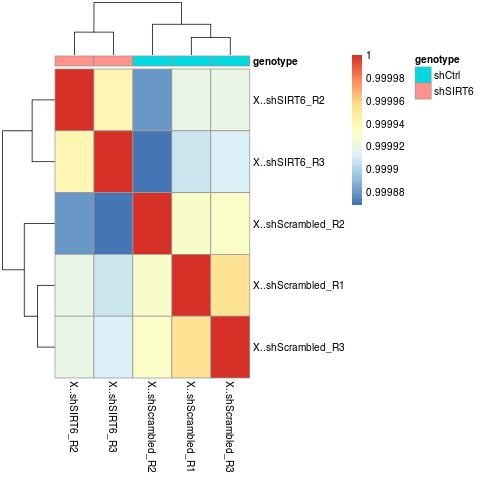

In [79]:
%%R

rld_mat <- assay(rld)

rld_cor <- cor(rld_mat)
pheatmap(rld_cor, annotation = meta)

### Statistical testing

using pre-existing size factors
estimating dispersions
gene-wise dispersion estimates
mean-dispersion relationship
final dispersion estimates
fitting model and testing
using 'normal' for LFC shrinkage, the Normal prior from Love et al (2014).

Note that type='apeglm' and type='ashr' have shown to have less bias than type='normal'.
See ?lfcShrink for more details on shrinkage type, and the DESeq2 vignette.
Reference: https://doi.org/10.1093/bioinformatics/bty895


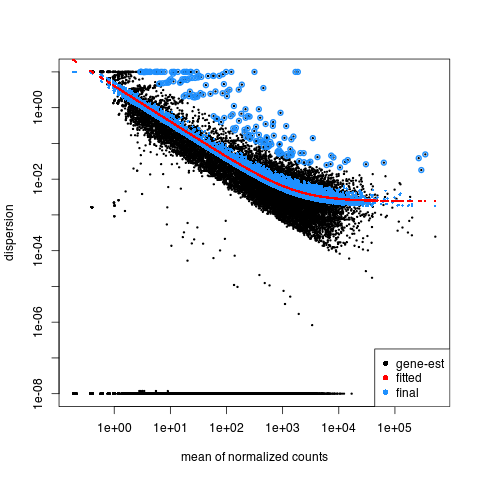

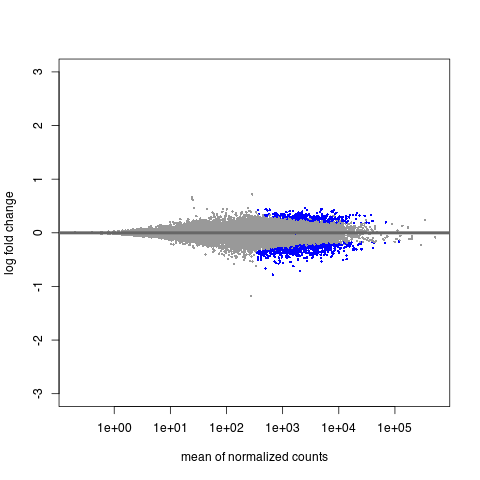

In [80]:
%%R

dds_analysis <- DESeq(dds)

plotDispEsts(dds_analysis)

contrast <- c("genotype", "shSIRT6", "shCtrl")

res_unshrunken <- results(dds_analysis, contrast=contrast, alpha = 0.05)

res <- lfcShrink(dds_analysis, contrast=contrast, res=res_unshrunken, type='normal')

plotMA(res, ylim=c(-3,3))

In [81]:
%%R

summary(res)

padj.cutoff <- 0.05

res_tb <- res %>% data.frame() %>% rownames_to_column(var="gene") %>% as_tibble()
sig <- res_tb %>%dplyr::filter(padj < padj.cutoff)
res.df <- as.data.frame(res)

res.df$gene_id <- rownames(res.df)
res.df.an <- left_join(res.df, genedb2, by='gene_id')

sig_s6 <- left_join(sig, genedb2, by=c('gene'='gene_id'))

#write.csv(sig_s6, '/tank/projects/smirnov_rnaseq/kashuk_et_al/sig_genes_pvalue_0_05_shSIRT6_shCtrl.csv')
#write.csv(res.df.an, '/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_shSIRT6_shCtrl.csv')


out of 25433 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 331, 1.3%
LFC < 0 (down)     : 562, 2.2%
outliers [1]       : 1, 0.0039%
low counts [2]     : 15786, 62%
(mean count < 354)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



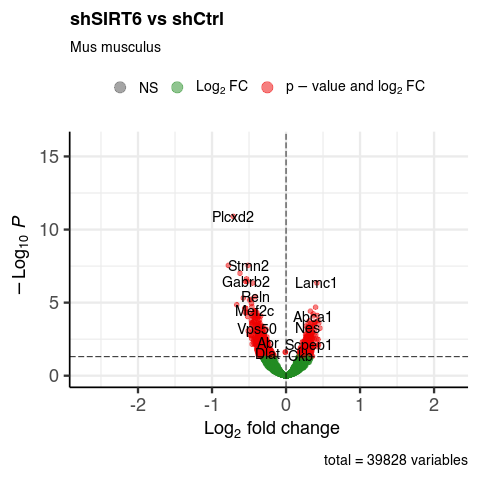

In [82]:
%%R

EnhancedVolcano(res.df.an,
                lab = res.df.an$symbol, 
                x = 'log2FoldChange',
                y = 'padj', 
                title = 'shSIRT6 vs shCtrl',
                subtitle = 'Mus musculus',
                pCutoff = 0.05, 
                FCcutoff = 0)

### Tximport for Step1, Step2, Control samples

In [83]:
%%R

samples <- list.files(path = "/tank/projects/kashuk_sirt6_hic/ad/rnaseq/salmon_quants", full.names = T) 
samples

files <- file.path(samples, "quant.sf")
files

names(files) <- str_replace(samples, "/tank/projects/kashuk_sirt6_hic/ad/rnaseq/salmon_quants", "")
files


txi <- tximport(files, 
                type="salmon", 
                tx2gene=tx2gene[,c("tx_id", "gene_id")],
                countsFromAbundance="lengthScaledTPM")

attributes(txi)

data <- data.frame(round(txi$counts))

reading in files with read_tsv
1 2 3 4 5 6 
transcripts missing from tx2gene: 5640
summarizing abundance
summarizing counts
summarizing length


In [84]:
%%R

genotype <- factor(c(rep("Control", 2), rep("Step1",2), rep("Step2",2)))

meta <- data.frame(genotype, row.names = colnames(data))
meta

            genotype
X.baseline1  Control
X.baseline2  Control
X.stage1_1     Step1
X.stage1_2     Step1
X.stage2_1     Step2
X.stage2_2     Step2


### Normalization

In [85]:
%%R

dds <- DESeqDataSetFromMatrix(countData = data, colData = meta, design = ~ genotype)

dds <- estimateSizeFactors(dds)
sizeFactors(dds)

colSums(counts(dds))

normalized_counts <- counts(dds, normalized=TRUE)

converting counts to integer mode


### Quality control

In [86]:
%%R

rld <- rlog(dds, blind=TRUE)

#### PCA

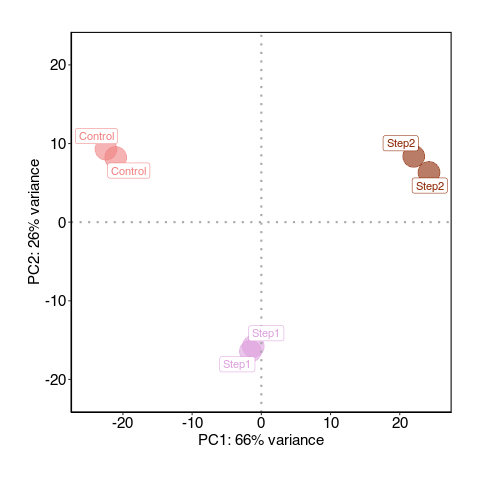

In [87]:
%%R

intgroup <- "genotype"
ntop <- 300

rv <- rowVars(assay(rld))

select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, length(rv)))]

pca <- prcomp(t(assay(rld)[select, ]))

percentVar <- pca$sdev^2/sum(pca$sdev^2)

intgroup.df <- as.data.frame(colData(rld)[, intgroup, drop = FALSE])
group <- if (length(intgroup) > 1) {
  factor(apply(intgroup.df, 1, paste, collapse = " : "))
} else {
  colData(rld)[[intgroup]]
}

d1 <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], intgroup.df, name = colnames(rld))

d1$genotype <- c(rep('Control', 2), rep('Step1', 2), rep('Step2', 2))

ggplot(d1, aes(x=PC1, y=PC2, colour = genotype)) + 
  geom_point(size=10, alpha = 0.6) +
  ylim(-22, 22) + xlim(-25, 25) +
  xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
  ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) +
  geom_hline(yintercept = 0, linetype='dotted', col = 'darkgrey', size=1) +
  geom_vline(xintercept = 0, linetype='dotted', col = 'darkgrey', size=1) +
  theme_classic() +
  geom_label_repel(aes(label = genotype),
                   box.padding   = 0.3, 
                   point.padding = 0.1,
                   segment.color = 'grey50',
                   force         = 0.1,
                   segment.size  = 0.2,
                   max.overlaps = 100,
                   angle = 40
  ) +
  theme(axis.text.y   = element_text(size=15,colour = "black"),
        axis.text.x   = element_text(size=15,colour = "black"),
        axis.title.y  = element_text(size=15,colour = "black"),
        axis.title.x  = element_text(size=15,colour = "black"),
        axis.line = element_line(colour = "black"),
        panel.border = element_rect(colour = "black", fill=NA, size=1),
        legend.position = "none",
        aspect.ratio = 4/4,
        plot.margin = unit(c(1,1,1,1), "cm")
  ) +
  scale_colour_manual(values = c('lightcoral', 'plum', 'orangered4'))

#ggsave('/tank/projects/kashuk_sirt6_hic/supplement/PCA_Step1_Step2_Control.pdf', dpi = 1200)

#### Correlation heatmap

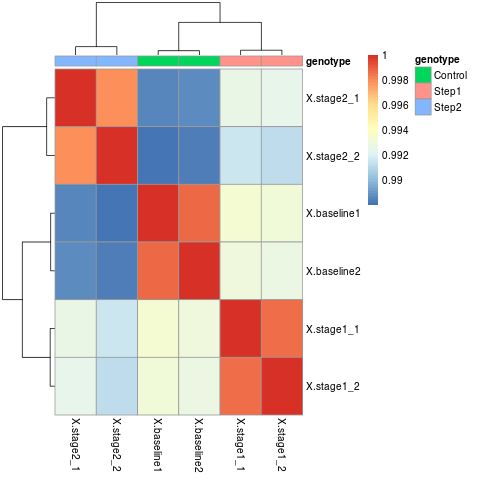

In [88]:
%%R

rld_mat <- assay(rld)

rld_cor <- cor(rld_mat)
pheatmap(rld_cor, annotation = meta)

### Statistical testing

In [89]:
### Step1 vs Control

using pre-existing size factors
estimating dispersions
gene-wise dispersion estimates
mean-dispersion relationship
final dispersion estimates
fitting model and testing
using 'normal' for LFC shrinkage, the Normal prior from Love et al (2014).

Note that type='apeglm' and type='ashr' have shown to have less bias than type='normal'.
See ?lfcShrink for more details on shrinkage type, and the DESeq2 vignette.
Reference: https://doi.org/10.1093/bioinformatics/bty895


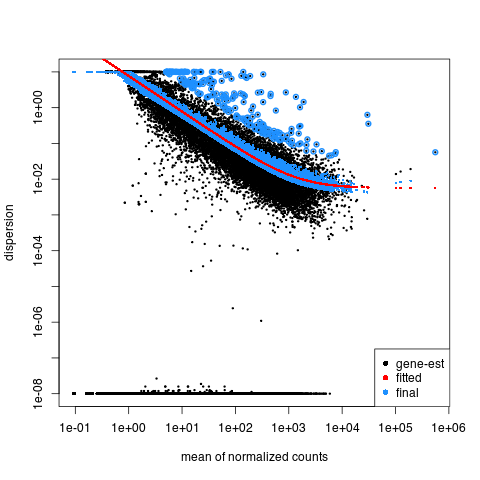

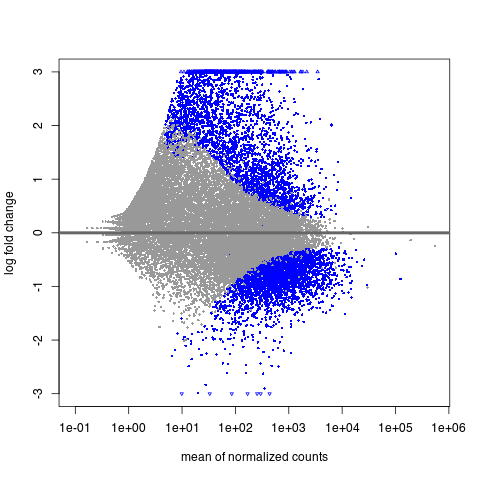

In [90]:
%%R

dds_analysis <- DESeq(dds)

plotDispEsts(dds_analysis)

contrast <- c("genotype", "Step1", "Control")

res_unshrunken <- results(dds_analysis, contrast=contrast, alpha = 0.05)

res <- lfcShrink(dds_analysis, contrast=contrast, res=res_unshrunken, type='normal')

plotMA(res, ylim=c(-3,3))

In [91]:
%%R

summary(res)

padj.cutoff <- 0.05
lfc.cutoff <- 0

res_tb <- res %>% data.frame() %>% rownames_to_column(var="gene") %>% as_tibble()
sig <- res_tb %>%dplyr::filter(padj < padj.cutoff & abs(log2FoldChange) >= lfc.cutoff)

res.df <- as.data.frame(res)

res.df$gene_id <- rownames(res.df)
res.df.an <- left_join(res.df, genedb2, by='gene_id')

sig_step1 <- left_join(sig, genedb2, by=c('gene'='gene_id'))

#write.csv(sig_step1, '/tank/projects/smirnov_rnaseq/kashuk_et_al/sig_genes_pvalue_0_05_Step1_Control.csv')
#write.csv(res.df.an, '/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Step1_Control.csv')


out of 28247 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 3208, 11%
LFC < 0 (down)     : 2878, 10%
outliers [1]       : 0, 0%
low counts [2]     : 8573, 30%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [92]:
### Step2 vs Control

using pre-existing size factors
estimating dispersions
gene-wise dispersion estimates
mean-dispersion relationship
final dispersion estimates
fitting model and testing
using 'normal' for LFC shrinkage, the Normal prior from Love et al (2014).

Note that type='apeglm' and type='ashr' have shown to have less bias than type='normal'.
See ?lfcShrink for more details on shrinkage type, and the DESeq2 vignette.
Reference: https://doi.org/10.1093/bioinformatics/bty895


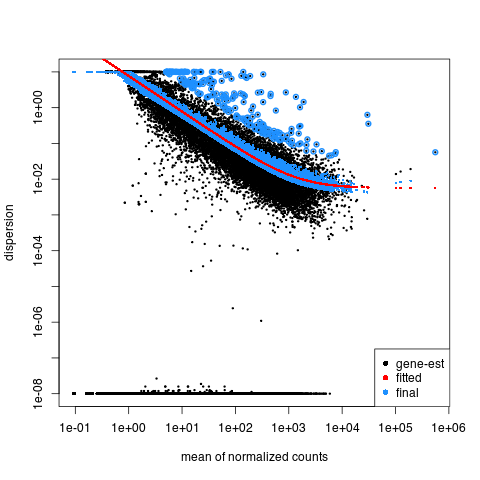

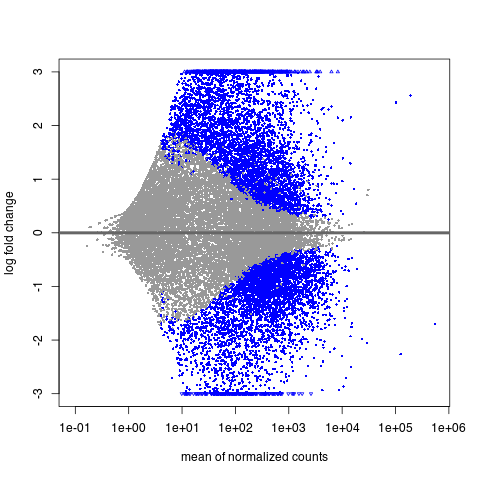

In [93]:
%%R

dds_analysis <- DESeq(dds)

plotDispEsts(dds_analysis)

contrast <- c("genotype", "Step2", "Control")

res_unshrunken <- results(dds_analysis, contrast=contrast, alpha = 0.05)

res <- lfcShrink(dds_analysis, contrast=contrast, res=res_unshrunken, type='normal')

plotMA(res, ylim=c(-3,3))

In [97]:
%%R

summary(res)

padj.cutoff <- 0.05
lfc.cutoff <- 0

res_tb <- res %>% data.frame() %>% rownames_to_column(var="gene") %>% as_tibble()
sig <- res_tb %>%dplyr::filter(padj < padj.cutoff & abs(log2FoldChange) >= lfc.cutoff)

res.df <- as.data.frame(res)

res.df$gene_id <- rownames(res.df)
res.df.an <- left_join(res.df, genedb2, by='gene_id')

sig_step2 <- left_join(sig, genedb2, by=c('gene'='gene_id'))

#write.csv(sig_step2, '/tank/projects/smirnov_rnaseq/kashuk_et_al/sig_genes_pvalue_0_05_Step2_Control.csv')
#write.csv(res.df.an, '/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Step2_Control.csv')


out of 28247 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 4886, 17%
LFC < 0 (down)     : 4231, 15%
outliers [1]       : 0, 0%
low counts [2]     : 9109, 32%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



### Vienn diagramm of DEGs

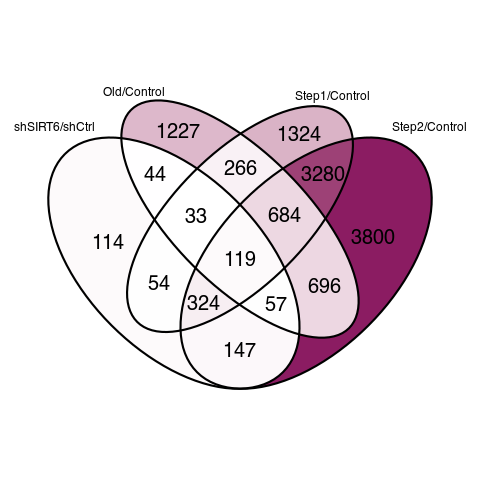

In [99]:
%%R

library(reshape2)
library(ggVennDiagram)

ko <- read.csv('/tank/projects/smirnov_rnaseq/kashuk_et_al/sig_genes_pvalue_0_05_shSIRT6_shCtrl.csv', row.names = 1)
s1 <- read.csv('/tank/projects/smirnov_rnaseq/kashuk_et_al/sig_genes_pvalue_0_05_Step1_Control.csv', row.names = 1)
s2 <- read.csv('/tank/projects/smirnov_rnaseq/kashuk_et_al/sig_genes_pvalue_0_05_Step2_Control.csv', row.names = 1)
old <- read.csv('/tank/projects/smirnov_rnaseq/kashuk_et_al/sig_genes_pvalue_0_05_Old_Control.csv', row.names = 1)

gene_list <- list('shSIRT6/shCtrl' = ko$symbol, 'Old/Control' = old$symbol, 'Step1/Control' = s1$symbol, 'Step2/Control' = s2$symbol)

ggVennDiagram(gene_list, label = "count", label_alpha = 0, label_size =7) + 
  scale_fill_gradient(low = "white", high = "maroon4") + 
  theme(
    legend.position = "none", 
    text = element_text(size = 16), 
    strip.text = element_text(size = 25),  
    panel.grid = element_blank(),  # Remove grid
    plot.margin = margin(10, 10, 10, 10)
  ) +
  scale_x_continuous(expand = expansion(mult = 0.1))

#ggsave('/tank/projects/kashuk_sirt6_hic/supplement/Figure6_DEGs_diagram.pdf', dpi = 1200)

### GeneOverlap analysis

In [135]:
%%R
library(GeneOverlap)
library(circlize)

dm.up <- list(`Old` = sig_old %>% filter(log2FoldChange > 0) %>% .$gene, 
              `Step1` = sig_step1 %>% filter(log2FoldChange > 0) %>% .$gene, 
              `Step2` = sig_step2 %>% filter(log2FoldChange > 0) %>% .$gene)

dm.down <- list(`Old` = sig_old %>% filter(log2FoldChange < 0) %>% .$gene, 
                `Step1` = sig_step1 %>% filter(log2FoldChange < 0) %>% .$gene, 
                `Step2` = sig_step2 %>% filter(log2FoldChange < 0) %>% .$gene)

s6ko.up <- list(`S6-KO Down` = sig_s6 %>% filter(log2FoldChange < 0) %>% .$gene, 
                `S6-KO Up` = sig_s6 %>% filter(log2FoldChange > 0) %>% .$gene)

ko_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_shSIRT6_shCtrl.csv', row.names = 1)
old_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Old_Control.csv', row.names = 1)
s1_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Step1_Control.csv', row.names = 1)
s2_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Step2_Control.csv', row.names = 1)

## Only expressing genes as background
s1_all_filt <- s1_all %>% 
  dplyr::filter(baseMean > 0)
s2_all_filt <- s2_all %>% 
  dplyr::filter(baseMean > 0)
ko_all_filt <- ko_all %>% 
  dplyr::filter(baseMean > 0)
old_all_filt <- ko_all %>% 
  dplyr::filter(baseMean > 0)

all_genes <- Reduce(intersect, list(s1_all_filt$gene_id, s2_all_filt$gene_id, ko_all_filt$gene_id, old_all_filt$gene_id))

In [136]:
%%R

gom.obj.up <- newGOM(dm.up, s6ko.up, length(all_genes))
gom.obj.down <- newGOM(dm.down, s6ko.up, length(all_genes))

In [137]:
%%R

pv.mat.up <- getMatrix(gom.obj.up, "pval") 
plot.mat.up <- getMatrix(gom.obj.up, "Jaccard") 

pv.mat.down <- getMatrix(gom.obj.down, "pval") 
plot.mat.down <- getMatrix(gom.obj.down, "Jaccard") 

pv.mat.up <- matrix(p.adjust(pv.mat.up, method='BH'), nrow=nrow(pv.mat.up))
pv.mat.down <- matrix(p.adjust(pv.mat.down, method='BH'), nrow=nrow(pv.mat.down))

insig.val <- 0
cutoff <- 0.05

note.mat.up <- format(pv.mat.up, digits=2)
note.mat.up[pv.mat.up < 0.05] <- format(pv.mat.up, digits=2, scientific=T)[pv.mat.up < 0.05]
note.mat.up[pv.mat.up > 0.05] <- "N.S."

note.mat.down <- format(pv.mat.down, digits=1)
note.mat.down[pv.mat.down < 0.05] <- format(pv.mat.down, digits=1, scientific=T)[pv.mat.down < 0.05]
note.mat.down[pv.mat.down > 0.05] <- "N.S."

col_fun = circlize::colorRamp2(seq(0, 0.155, 0.018), brewer.pal(9, "Blues"))

In [138]:
%%R

library(ComplexHeatmap)

h.up <- Heatmap(plot.mat.up, name = 'Jaccard\nIndex', show_heatmap_legend = F, show_column_names = F,
                cluster_rows = F, 
                cluster_columns = F, 
                col = col_fun,
                cell_fun = function(j, i, x, y, width, height, fill) {
                    grid.text(note.mat.up[i, j], x, y, gp = gpar(fontsize = 16, col = "black"))
                },
                column_names_rot = 0, column_names_side = "top", column_names_centered = T,
                row_title = "Up-regulated", row_title_side = "right",
                rect_gp = gpar(col = "black", lwd = 1.5))

h.down <- Heatmap(plot.mat.down, name = ' Jaccard\nIndex', show_heatmap_legend = F,
                  cluster_rows = F, 
                  cluster_columns = F, 
                  col = col_fun, 
                  cell_fun = function(j, i, x, y, width, height, fill) {
                    grid.text(note.mat.down[i, j], x, y, gp = gpar(fontsize = 16, col = "black"))
                  },
                  column_names_rot = 0, column_names_side = "top", column_names_centered = T,
                  row_title = "Down-regulated", row_title_side = "right",
                  rect_gp = gpar(col = "black", lwd = 1.5))

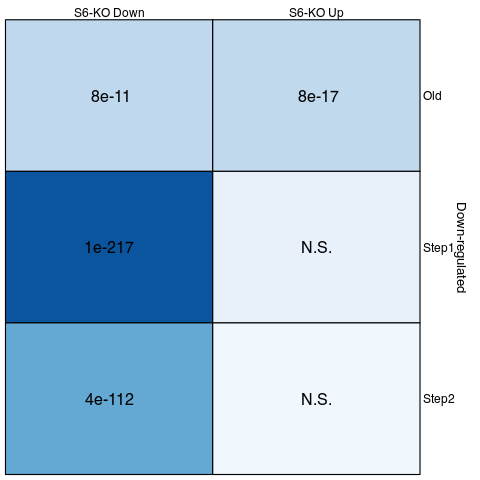

In [139]:
%%R
draw(h.down, merge_legend = TRUE)

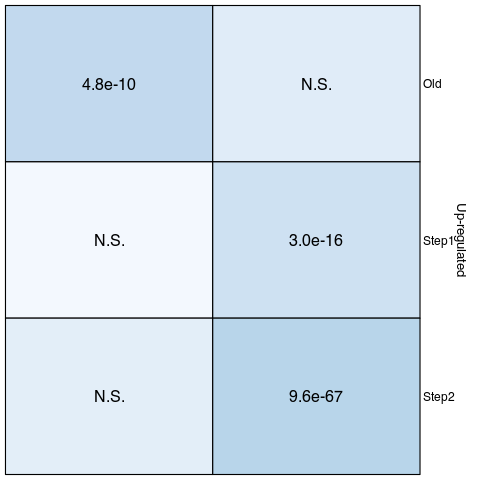

In [140]:
%%R
draw(h.up, merge_legend = TRUE)

### REACTOME analysis

In [141]:
%%R

## Background

ko_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_shSIRT6_shCtrl.csv', row.names = 1)
s1_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Step1_Control.csv', row.names = 1)
s2_all <- read.csv('/tank/projects/kashuk_rnaseq/results_rnaseq/all_genes_Step2_Control.csv', row.names = 1)

## Only expressing genes as background
s1_all_filt <- s1_all %>% 
  dplyr::filter(baseMean > 0)
s2_all_filt <- s2_all %>% 
  dplyr::filter(baseMean > 0)
ko_all_filt <- ko_all %>% 
  dplyr::filter(baseMean > 0)

all_genes <- union(s1_all_filt$symbol, s2_all_filt$symbol)
all_genes <- unique(union(all_genes, ko_all_filt$symbol))

mart <- useEnsembl("ENSEMBL_MART_ENSEMBL", dataset="mmusculus_gene_ensembl", version=108)

back <- getBM(filters = "external_gene_name",
              attributes = c("entrezgene_id","ensembl_gene_id", "external_gene_name", "gene_biotype", "description"),
              values = all_genes, 
              mart = mart)


In [142]:
## Intersect DEGs 

In [143]:
%%R

ko <- read.csv('/tank/projects/smirnov_rnaseq/kashuk_et_al/sig_genes_pvalue_0_05_shSIRT6_shCtrl.csv', row.names = 1)
s1 <- read.csv('/tank/projects/smirnov_rnaseq/kashuk_et_al/sig_genes_pvalue_0_05_Step1_Control.csv', row.names = 1)
s2 <- read.csv('/tank/projects/smirnov_rnaseq/kashuk_et_al/sig_genes_pvalue_0_05_Step2_Control.csv', row.names = 1)

ko_s1_up <- subset(ko, symbol %in% intersect(ko %>% filter(log2FoldChange > 0) %>% .$symbol, 
                                             s1 %>% filter(log2FoldChange > 0) %>% .$symbol))

ko_s1_down <- subset(ko, symbol %in% intersect(ko %>% filter(log2FoldChange < 0) %>% .$symbol, 
                                             s1 %>% filter(log2FoldChange < 0) %>% .$symbol))

ko_s2_up <- subset(ko, symbol %in% intersect(ko %>% filter(log2FoldChange > 0) %>% .$symbol, 
                                             s2 %>% filter(log2FoldChange > 0) %>% .$symbol))

ko_s2_down <- subset(ko, symbol %in% intersect(ko %>% filter(log2FoldChange < 0) %>% .$symbol, 
                                             s2 %>% filter(log2FoldChange < 0) %>% .$symbol))

In [144]:
## Step1/Control & shSIRT6/shCtrl

In [145]:
%%R

library(ReactomePA)
library(enrichplot)

gene_annotations_up <- getBM(
  filters = "external_gene_name",
  attributes = c("entrezgene_id", "ensembl_gene_id", "external_gene_name", "gene_biotype", "description"),
  values = unique(ko_s1_up$symbol), 
  mart = mart
)

gene_annotations_down <- getBM(
  filters = "external_gene_name",
  attributes = c("entrezgene_id", "ensembl_gene_id", "external_gene_name", "gene_biotype", "description"),
  values = unique(ko_s1_down$symbol), 
  mart = mart
)

upregulated <- merge(
  ko_s1_up, 
  gene_annotations_up, 
  by.x = 'symbol', 
  by.y = 'external_gene_name'
)

downregulated <- merge(
  ko_s1_down, 
  gene_annotations_down, 
  by.x = 'symbol', 
  by.y = 'external_gene_name'
)

# Pathway analysis 
pathway_analysis <- list(
  upregulated = enrichPathway(
    gene = upregulated$entrezgene_id,
    universe = as.character(back$entrezgene_id),
    organism = 'mouse',
    pvalueCutoff = 0.05,
    readable = TRUE
  ),
  
  downregulated = enrichPathway(
    gene = downregulated$entrezgene_id,
    universe = as.character(back$entrezgene_id),
    organism = 'mouse',
    pvalueCutoff = 0.05,
    readable = TRUE
  )
)


In [146]:
%%R

edo_up_step1 <- pairwise_termsim(pathway_analysis$upregulated)
edo_down_step1 <- pairwise_termsim(pathway_analysis$downregulated)

results <- list(
  upregulated_pathways = as.data.frame(pathway_analysis$upregulated),
  downregulated_pathways = as.data.frame(pathway_analysis$downregulated),

  edo_upregulated = as.data.frame(edo_up_step1),
  edo_downregulated = as.data.frame(edo_down_step1)
)

In [147]:
%%R

write.csv(results$edo_upregulated, '/tank/projects/smirnov_rnaseq/kashuk_et_al/reactome_upregulated_common_DEGs_shSIRT6_Step1.csv')
write.csv(results$edo_downregulated, '/tank/projects/smirnov_rnaseq/kashuk_et_al/reactome_downregulated_common_DEGs_shSIRT6_Step1.csv')

In [148]:
## Step2/Control & shSIRT6/shCtrl

In [149]:
%%R

library(enrichplot)

gene_annotations_up <- getBM(
  filters = "external_gene_name",
  attributes = c("entrezgene_id", "ensembl_gene_id", "external_gene_name", "gene_biotype", "description"),
  values = unique(ko_s2_up$symbol), 
  mart = mart
)

gene_annotations_down <- getBM(
  filters = "external_gene_name",
  attributes = c("entrezgene_id", "ensembl_gene_id", "external_gene_name", "gene_biotype", "description"),
  values = unique(ko_s2_down$symbol), 
  mart = mart
)

upregulated <- merge(
  ko_s2_up, 
  gene_annotations_up, 
  by.x = 'symbol', 
  by.y = 'external_gene_name'
)

downregulated <- merge(
  ko_s2_down, 
  gene_annotations_down, 
  by.x = 'symbol', 
  by.y = 'external_gene_name'
)


# Pathway analysis 
pathway_analysis <- list(
  upregulated = enrichPathway(
    gene = upregulated$entrezgene_id,
    universe = as.character(back$entrezgene_id),
    organism = 'mouse',
    pvalueCutoff = 0.05,
    readable = TRUE
  ),
  
  downregulated = enrichPathway(
    gene = downregulated$entrezgene_id,
    universe = as.character(back$entrezgene_id),
    organism = 'mouse',
    pvalueCutoff = 0.05,
    readable = TRUE
  )
)

edo_up_step2 <- pairwise_termsim(pathway_analysis$upregulated)
edo_down_step2 <- pairwise_termsim(pathway_analysis$downregulated)

results <- list(
  upregulated_pathways = as.data.frame(pathway_analysis$upregulated),
  downregulated_pathways = as.data.frame(pathway_analysis$downregulated),

  edo_upregulated = as.data.frame(edo_up_step2),
  edo_downregulated = as.data.frame(edo_down_step2)
)

In [150]:
%%R

write.csv(results$edo_upregulated, '/tank/projects/smirnov_rnaseq/kashuk_et_al/reactome_upregulated_common_DEGs_shSIRT6_Step2.csv')
write.csv(results$edo_downregulated, '/tank/projects/smirnov_rnaseq/kashuk_et_al/reactome_downregulated_common_DEGs_shSIRT6_Step2.csv')

## Lollipop plot

In [151]:
## Up-regulated

In [152]:
%%R

#Checking the intersection between top20 enriched categories in step1 and step2
intersect(as.data.frame(edo_up_step1) %>% head(20) %>% .$Description, 
          as.data.frame(edo_up_step2) %>% head(20) %>% .$Description) 

 [1] "Condensation of Prophase Chromosomes"                                                 
 [2] "Mitotic Prophase"                                                                     
 [3] "PRC2 methylates histones and DNA"                                                     
 [4] "RUNX1 regulates genes involved in megakaryocyte differentiation and platelet function"
 [5] "M Phase"                                                                              
 [6] "Regulation of endogenous retroelements"                                               
 [7] "Regulation of endogenous retroelements by KRAB-ZFP proteins"                          
 [8] "DNA Damage/Telomere Stress Induced Senescence"                                        
 [9] "RMTs methylate histone arginines"                                                     
[10] "HDACs deacetylate histones"                                                           
[11] "HDMs demethylate histones"                                      

In [153]:
%%R
library(DOSE)

ntop = 20

shared_up_edo <- left_join(as.data.frame(edo_up_step1) %>% head(ntop) %>% dplyr::select(Description, p.adjust, Count), 
                        as.data.frame(edo_up_step2) %>% head(ntop) %>% dplyr::select(Description, p.adjust, Count), 
                        by = c("Description"))

colnames(shared_up_edo) <- c("Description", "Step1_padj", "Step1_Count", "Step2_padj", "Step2_Count")

shared_up_edo <- shared_up_edo %>%
  mutate(
    Step1_log10p = -log10(Step1_padj),
    Step2_log10p = -log10(Step2_padj)
  ) %>%
  arrange(desc(Step1_log10p + Step2_log10p))

plot_data <- shared_up_edo %>%
  mutate(Description = factor(Description, levels = rev(Description))) %>%
  pivot_longer(
    cols = c(Step1_log10p, Step2_log10p),
    names_to = "Comparison",
    values_to = "log10p"
  ) %>%
  mutate(
    Comparison = factor(Comparison, 
                       levels = c("Step1_log10p", "Step2_log10p"),
                       labels = c("Step 1", "Step 2")),
    Count = ifelse(Comparison == "Step 1", Step1_Count, Step2_Count)
  )

In [154]:
%%R

cell_cycle <- c("M Phase", 
                "Mitotic Prophase", 
                "Condensation of Prophase Chromosomes")

transcription_reg <- c("Epigenetic regulation of gene expression", 
                       "PRC2 methylates histones and DNA", 
                       "Transcriptional regulation by RUNX1", 
                       "RUNX1 regulates genes involved in megakaryocyte differentiation and platelet function", 
                       "Estrogen-dependent gene expression", 
                       "Interleukin-7 signaling", 
                       "Regulation of endogenous retroelements", 
                       "Regulation of endogenous retroelements by KRAB-ZFP proteins")

chromatin_mod <- c("Chromatin modifying enzymes", 
                   "Chromatin organization", 
                   "PKMTs methylate histone lysines", 
                   "RMTs methylate histone arginines", 
                   "HDACs deacetylate histones", 
                   "HDMs demethylate histones", 
                   "HATs acetylate histones")

cell_senescence <- c("DNA Damage/Telomere Stress Induced Senescence", 
                     "Cellular Senescence")

pathway_list <- list("Cell cycle" = cell_cycle, 
                     "Transcription and retroelement regulation" = transcription_reg, 
                     "Chromatin modifications" = chromatin_mod, 
                     "Cellular senescence" = cell_senescence)

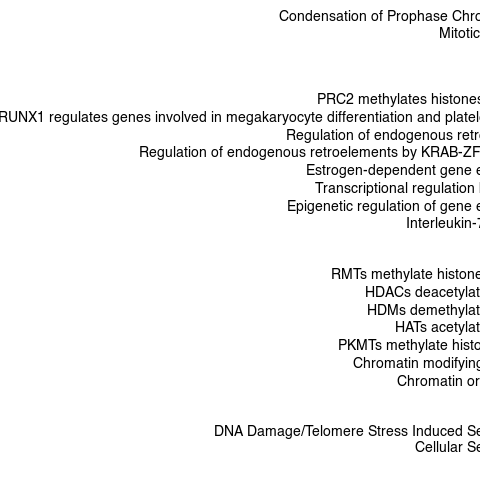

In [155]:
%%R

grey_base <- "grey50"
grey_dark <- "grey25"

figure_list <- list()
for (name in names(pathway_list)){
    pathway_group <- plot_data %>% 
                     filter(Description %in% pathway_list[[name]])
    
    p <- ggplot(pathway_group, aes(x = log10p, y = Description)) +
            #geom_line(aes(group = Description), color = "grey50", linewidth = 1.8) +
            stat_summary(geom = "linerange",  
                         fun.min = "min", 
                         fun.max = "max", 
                         color = grey_base, linewidth = 0.8) +
            geom_point(aes(size = Count), shape = 21, color = "white", fill = "white", stroke = 0.5) +
            geom_point(aes(fill = Comparison, size = Count), shape = 21, alpha = 0.8, color = "white", stroke = 0.5, show.legend = TRUE) +
            geom_point(aes(size = Count), shape = 21, color = "white", fill = NA, stroke = 0.5) +
            scale_fill_manual(values = c("Step 1" = "#58593FCC", 
                                          "Step 2" = "#350E20CC")) +
            scale_x_continuous(name = NULL, limits = c(8, 24), breaks = seq(8, 24, 4)) +
            #scale_y_discrete(name = NULL, labels = function(x) str_wrap(x, width = 225)) +
            ylab("")+
            scale_size_continuous(limits = c(9, 36), range = c(3, 6)) + 
            theme_dose(14) + 
            theme(legend.position = "none", 
                  axis.title.y = element_text(margin = margin(r = 65))
            )

    figure_list[[name]] <- p
}


ggpubr::ggarrange(plotlist = figure_list, 
                  ncol = 1, nrow = 4, 
                  align = "v", 
                  heights = c(1.20, 2.55, 2.3, 0.95))

### Heatmap of log2(Fold Changes) of upregulated DEGs common between shSIRT6/shCtrl, Step1/Control and Step2/Control

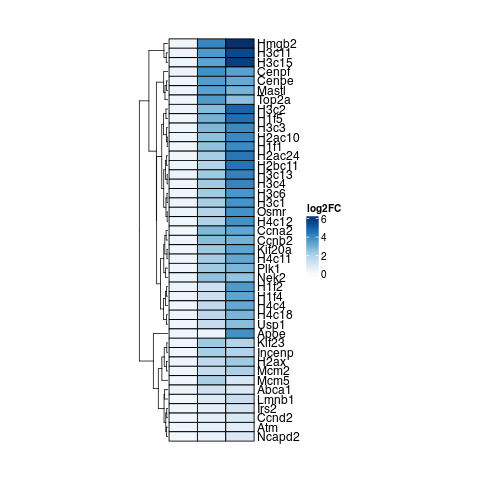

In [156]:
%%R

library(biomaRt)
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library(circlize)
library(grid) 

mart <- useEnsembl("ENSEMBL_MART_ENSEMBL",
                   dataset = "mmusculus_gene_ensembl",
                   version = 108)

# Read Reactome comparisons, extract common genes
reactome_paths <- list(
  KO_Step1 = '/tank/projects/smirnov_rnaseq/kashuk_et_al/reactome_upregulated_common_DEGs_shSIRT6_Step1.csv',
  KO_Step2 = '/tank/projects/smirnov_rnaseq/kashuk_et_al/reactome_upregulated_common_DEGs_shSIRT6_Step2.csv'
)

react_df <- lapply(names(reactome_paths), function(tag) {
  read.csv(reactome_paths[[tag]], stringsAsFactors = FALSE) %>%
    mutate(tag = tag,
           gene = strsplit(as.character(geneID), "/")) %>%
    unnest(gene)
}) %>% bind_rows()

# Pathways in both comparisons
common_paths <- react_df %>%
  count(Description, tag) %>%
  group_by(Description) %>%
  filter(n() == length(unique(tag))) %>%
  pull(Description)

# Genes in those pathways in both
common_genes <- react_df %>%
  filter(Description %in% common_paths) %>%
  distinct(tag, gene) %>%
  count(gene) %>%
  filter(n == length(unique(react_df$tag))) %>%
  pull(gene)

# Annotation
ann <- getBM(filters    = "external_gene_name",
             attributes = c("external_gene_name","ensembl_gene_id","description"),
             values     = common_genes,
             mart       = mart)

# Read & stack DEG tables, filtering to those Ensembl IDs
deg_paths <- list(
  `S6-KO` = '/tank/projects/smirnov_rnaseq/kashuk_et_al/sig_genes_pvalue_0_05_shSIRT6_shCtrl.csv',
  Step1   = '/tank/projects/smirnov_rnaseq/kashuk_et_al/sig_genes_pvalue_0_05_Step1_Control.csv',
  Step2   = '/tank/projects/smirnov_rnaseq/kashuk_et_al/sig_genes_pvalue_0_05_Step2_Control.csv'
)

df_long <- bind_rows(lapply(names(deg_paths), function(lbl) {
  read.csv(deg_paths[[lbl]],
           sep = ifelse(grepl("\\.csv$", deg_paths[[lbl]]), ",", ";"),
           stringsAsFactors = FALSE) %>%
    filter(gene %in% ann$ensembl_gene_id) %>%
    transmute(
      gene_id = symbol,
      log2fc  = log2FoldChange,
      type    = lbl
    )
})) %>%
  mutate(type = factor(type, levels = c("S6-KO", "Step1", "Step2")))

df_wide <- df_long %>%
  arrange(gene_id) %>%
  pivot_wider(names_from = type, values_from = log2fc) 

df_wide <- as.data.frame(df_wide)
rownames(df_wide) <- df_wide$gene_id
df_wide$gene_id <- NULL  

mat = as.matrix(df_wide)
mat_scaled = t(apply(mat, 1, scale))

base_mean = rowMeans(mat)
type = gsub("s\\d+_", "", colnames(mat))

row_space <- unit(0.33, "cm")  
col_space <- unit(1, "cm")  

col_fun = colorRamp2(seq(0, max(df_long$log2fc), max(df_long$log2fc)/8), brewer.pal(9, "Blues"))

Heatmap(
  mat, 
  name = "log2FC",
  show_column_names = F,
  col = col_fun,
  column_names_rot = 0,
  show_row_names = TRUE,
  column_order = c("S6-KO", "Step1", "Step2"),
  row_names_gp = gpar(fontsize = 12), 
  rect_gp = gpar(col = "black", lwd = 1.2),
  row_labels = rownames(mat),  
  row_title_gp = gpar(fontsize = 8),
  width = ncol(mat) * col_space,
  height = nrow(mat) * row_space
)

### Summary line‐plot of mean log2FC per condition

R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1: Removed 3 rows containing non-finite outside the scale range
(`stat_summary()`). 
  
R callback write-console: 2: Removed 3 rows containing non-finite outside the scale range
(`stat_summary()`). 
  
R callback write-console: 3: Removed 3 rows containing non-finite outside the scale range
(`stat_summary()`). 
  


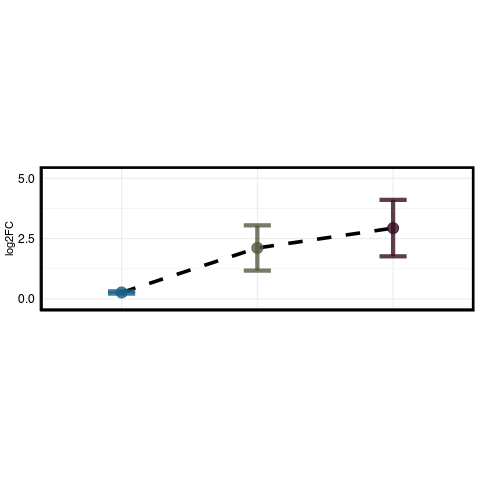

In [158]:
%%R

ggplot(df_long, aes(x=type, y=log2fc)) + 
    stat_summary(fun=mean, geom="line", aes(group=1), linetype = "dashed", size = 1.7) +
    stat_summary(aes(color = type), 
                 fun.data = mean_sdl, 
                 fun.args = list(mult=1), 
                 geom="errorbar", 
                 width=0.2, 
                 size = 2) + 
    stat_summary(aes(color = type), fun.y=mean, geom="point", size = 5) + 
    xlab(NULL) + ylab("log2FC")+
    theme_minimal() +
    theme(
        axis.text.y   = element_text(colour = "black", size = 12),
        axis.text.x   = element_blank(),
        axis.line     = element_line(colour = "black"),
        panel.border  = element_rect(colour = "black", fill = NA, size = 2.5),
        legend.position = "none",
        aspect.ratio  = 1/3
    ) +
    scale_y_continuous(limits = c(0, 5), breaks = c(0, 2.5, 5), expand = expansion(0.1))+
    scale_color_manual(values = c("#155F83CC", "#58593FCC", "#350E20CC")#c('cornflowerblue','grey','cyan')
                      ) 

In [159]:
%%R

sessionInfo()

R version 4.4.2 (2024-10-31)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 20.04.6 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/liblapack.so.3;  LAPACK version 3.9.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Moscow
tzcode source: system (glibc)

attached base packages:
 [1] grid      stats4    tools     stats     graphics  grDevices utils    
 [8] datasets  methods   base     

other attached packages:
 [1] circlize_0.4.16                       
 [2] DOSE_4.0.0                            
 [3] enrichplot_1.26.6                     
 [4] ReactomePA